# Executive Summary: 

This project forecasts the monthly U.S. unemployment rate by evaluating the predictive power of macroeconomic indicators. While univariate SARIMA models captured seasonal persistence, the integration of lagged exogenous variables—Initial Jobless Claims (1-month lag), Federal Funds Rate (12-month lag), and Industrial Production (6-month lag)—substantially improved accuracy. The final Lagged SARIMAX model reduced the Root Mean Square Error (RMSE) from 0.18 to 0.07, outperforming simple benchmarks and a COVID-period robustness check.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
import os

In [49]:

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

# 1. Update this path to the folder where your CSVs are located
# If they are in the same folder as this notebook, leave it as './'
data_path = 'Data/' 

# File configuration: Mapping CSV filenames to their internal variable names
files_config = {
    'FEDFUNDS.csv': 'FEDFUNDS',
    'ICSA.csv': 'ICSA',
    'INDPRO.csv': 'INDPRO',
    'PAYEMS.csv': 'PAYEMS',
    'RRSFS.csv': 'RRSFS',
    'UNRATENSA (1).csv': 'UNRATENSA'
}

def load_and_merge_local(path):
    """Reads local CSV files and merges them into a consistent monthly dataframe."""
    dfs = []
    
    for filename, colname in files_config.items():
        full_path = os.path.join(path, filename)
        
        if not os.path.exists(full_path):
            print(f"Warning: {filename} not found in {path}")
            continue
            
        # Read directly from local disk
        df = pd.read_csv(full_path)
        df['observation_date'] = pd.to_datetime(df['observation_date'])

        # Initial Claims (ICSA) is weekly; resample to Month-Start (MS) sum
        if colname == 'ICSA':
            df = df.set_index('observation_date').resample('MS').sum().reset_index()
        dfs.append(df)

    if not dfs:
        raise FileNotFoundError("No CSV files were found. Check your file paths.")

    # Merge all datasets on 'observation_date'
    df_merged = dfs[0]
    for i in range(1, len(dfs)):
        df_merged = pd.merge(df_merged, dfs[i], on='observation_date', how='outer')

    # Standardize index and interpolate any gaps
    df_merged = df_merged.sort_values('observation_date').set_index('observation_date')
    df_merged = df_merged.interpolate(method='linear')
    return df_merged

# Execute processing
data = load_and_merge_local(data_path)
print(f"\nProcessing Complete. Range: {data.index.min().date()} to {data.index.max().date()}")
print(data.head())


Processing Complete. Range: 1919-01-01 to 2026-02-01
                  FEDFUNDS  ICSA  INDPRO  PAYEMS  RRSFS  UNRATENSA
observation_date                                                  
1919-01-01             NaN   NaN  4.8739     NaN    NaN        NaN
1919-02-01             NaN   NaN  4.6585     NaN    NaN        NaN
1919-03-01             NaN   NaN  4.5238     NaN    NaN        NaN
1919-04-01             NaN   NaN  4.6046     NaN    NaN        NaN
1919-05-01             NaN   NaN  4.6315     NaN    NaN        NaN


In [50]:
data.reset_index().head()

,observation_date,FEDFUNDS,ICSA,INDPRO,PAYEMS,RRSFS,UNRATENSA
0,1919-01-01,NaN,NaN,4.8739,NaN,NaN,NaN
1,1919-02-01,NaN,NaN,4.6585,NaN,NaN,NaN
2,1919-03-01,NaN,NaN,4.5238,NaN,NaN,NaN
3,1919-04-01,NaN,NaN,4.6046,NaN,NaN,NaN
4,1919-05-01,NaN,NaN,4.6315,NaN,NaN,NaN


In [51]:
print("\nShape:")
print(data.shape)

print("\nColumns:")
print(list(data.columns))

print("\nData types:")
print(data.dtypes)

print("\nMissing values by column:")
print(data.isnull().sum())

print("\nRows with any missing values:")
print(data.isnull().any(axis=1).sum())

print("\nDuplicate timestamp count:")
print(data.index.duplicated().sum())

print("\nDate index check:")
print(f"Index type: {type(data.index)}")
print(f"Start date: {data.index.min().date()}")
print(f"End date  : {data.index.max().date()}")


Shape:
(1286, 6)

Columns:
['FEDFUNDS', 'ICSA', 'INDPRO', 'PAYEMS', 'RRSFS', 'UNRATENSA']

Data types:
FEDFUNDS     float64
ICSA         float64
INDPRO       float64
PAYEMS       float64
RRSFS        float64
UNRATENSA    float64
dtype: object

Missing values by column:
FEDFUNDS     426
ICSA         576
INDPRO         0
PAYEMS       240
RRSFS        876
UNRATENSA    348
dtype: int64

Rows with any missing values:
876

Duplicate timestamp count:
0

Date index check:
Index type: <class 'pandas.DatetimeIndex'>
Start date: 1919-01-01
End date  : 2026-02-01


# Modeling 

### Data Prep.

In [52]:
data_model = data.copy()

data_model = data_model[
    ["FEDFUNDS", "ICSA", "INDPRO", "PAYEMS", "RRSFS", "UNRATENSA"]
]

data_model.head()

,FEDFUNDS,ICSA,INDPRO,PAYEMS,RRSFS,UNRATENSA
observation_date,,,,,,
1919-01-01,NaN,NaN,4.8739,NaN,NaN,NaN
1919-02-01,NaN,NaN,4.6585,NaN,NaN,NaN
1919-03-01,NaN,NaN,4.5238,NaN,NaN,NaN
1919-04-01,NaN,NaN,4.6046,NaN,NaN,NaN
1919-05-01,NaN,NaN,4.6315,NaN,NaN,NaN


In [53]:
data_model["UNRATENSA"].dropna().index.min()

Timestamp('1948-01-01 00:00:00')

### Hypothesis modeling

Based on the exploratory analysis conducted earlier, several features of the unemployment time series suggest an appropriate modeling strategy for forecasting.

First, the unemployment rate exhibits strong persistence over time, as shown by the slow decay in the autocorrelation function (ACF). This indicates that current unemployment is strongly related to its past values. Therefore, autoregressive components are expected to be important in modeling the series.

Second, the data are observed at a monthly frequency, and the ACF revealed a noticeable seasonal structure around lag 12, suggesting the presence of annual seasonality. This motivates the use of seasonal time series models, such as SARIMA.

Third, unemployment is influenced by broader macroeconomic conditions. Economic indicators such as initial jobless claims (ICSA), the federal funds rate (FEDFUNDS), and industrial production (INDPRO) are theoretically linked to labor market conditions. Therefore, including these variables as exogenous predictors in a SARIMAX framework may improve forecasting performance relative to purely univariate models.

Fourth, the effects of macroeconomic variables on unemployment are unlikely to occur instantaneously. Economic adjustments often occur with delays, implying that lagged values of predictors may provide stronger predictive power. For this reason, lagged versions of the exogenous variables will also be explored.

Finally, the COVID-19 pandemic introduced an extreme but temporary shock to the labor market. Rather than removing this period from the dataset, the baseline models retain it in order to capture the full dynamics of the unemployment process. However, a robustness check using a COVID indicator variable will be conducted to examine whether explicitly modeling this shock improves forecasting performance.

Given these observations, the modeling strategy will proceed as follows:

- Establish baseline forecasting performance using simple benchmarks, including naive and seasonal naive models, along with a univariate SARIMA model.

- Extend the model to a SARIMAX framework by incorporating macroeconomic predictors.

- Explore lagged versions of the predictors to capture delayed economic effects and improve forecast accuracy.

- Compare all models using out-of-sample forecast performance metrics.

- Evaluate a COVID-dummy specification as a robustness check.

- Finally, compare the best time-series model with a simple machine learning benchmark.

This approach allows us to systematically evaluate whether incorporating economic information and lag structures improves the ability to forecast monthly unemployment rates.

### Baseline modeling

In [54]:
#### Create dataset for baseline models (univariate)
y = data_model["UNRATENSA"].dropna()

print(y.index.min(), y.index.max())
print(len(y))

1948-01-01 00:00:00 2026-02-01 00:00:00
938


In [55]:
#### Create dataset for SARIMAX (multivariate)
data_exog = data_model.loc["1992-01-01":].copy()

data_exog = data_exog.dropna()

print(data_exog.shape)
print(data_exog.index.min(), data_exog.index.max())


(410, 6)
1992-01-01 00:00:00 2026-02-01 00:00:00


RRSFS starts 1992

In [56]:
#### Sanity check
data_exog.isna().sum()

FEDFUNDS     0
ICSA         0
INDPRO       0
PAYEMS       0
RRSFS        0
UNRATENSA    0
dtype: int64

In [57]:
#### Train / test split
import numpy as np
import pandas as pd

# y already created earlier
# y = data_model["UNRATENSA"].dropna()

train = y.iloc[:-12]
test = y.iloc[-12:]

print("Train:", train.index.min(), train.index.max())
print("Test :", test.index.min(), test.index.max())
print(len(train), len(test))


Train: 1948-01-01 00:00:00 2025-02-01 00:00:00
Test : 2025-03-01 00:00:00 2026-02-01 00:00:00
926 12


#### Naive Model

In [58]:
naive_forecast = np.repeat(train.iloc[-1], len(test))

mae_naive = mean_absolute_error(test, naive_forecast)
rmse_naive = np.sqrt(mean_squared_error(test, naive_forecast))
mape_naive = np.mean(np.abs((test - naive_forecast) / test)) * 100

print("Naive")
print(mae_naive, rmse_naive, mape_naive)


Naive
0.23333333333333328 0.2915475947422651 5.627627071975266


#### Seasonal Naive 

In [59]:
seasonal_naive = train.iloc[-12:].values

mae_snaive = mean_absolute_error(test, seasonal_naive)
rmse_snaive = np.sqrt(mean_squared_error(test, seasonal_naive))
mape_snaive = np.mean(np.abs((test - seasonal_naive) / test)) * 100

print("Seasonal naive")
print(mae_snaive, rmse_snaive, mape_snaive)


Seasonal naive
0.24999999999999986 0.276887462097269 5.9156947989749


#### SARIMA(1,0,0)(1,0,0,12)

In [60]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train,
    order=(1,0,0),
    seasonal_order=(1,0,0,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit()

print(sarima_result.summary())


                                     SARIMAX Results                                      
Dep. Variable:                          UNRATENSA   No. Observations:                  926
Model:             SARIMAX(1, 0, 0)x(1, 0, 0, 12)   Log Likelihood                -675.765
Date:                            Fri, 13 Mar 2026   AIC                           1357.530
Time:                                    16:14:56   BIC                           1371.980
Sample:                                01-01-1948   HQIC                          1363.046
                                     - 02-01-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9884      0.006    175.695      0.000       0.977       0.999
ar.S.L12       0.4594      0.006   

##### Forecast SARIMA

In [61]:
forecast = sarima_result.get_forecast(steps=12)

pred_sarima = forecast.predicted_mean

mae_sarima = mean_absolute_error(test, pred_sarima)
rmse_sarima = np.sqrt(mean_squared_error(test, pred_sarima))
mape_sarima = np.mean(np.abs((test - pred_sarima) / test)) * 100

print("SARIMA")
print(mae_sarima, rmse_sarima, mape_sarima)


SARIMA
0.15708004684393717 0.17789118531809459 3.6359246245711443


In [62]:
### Comparision Table 
results_df = pd.DataFrame({
    "Model": ["Naive", "Seasonal Naive", "SARIMA"],
    "MAE": [mae_naive, mae_snaive, mae_sarima],
    "RMSE": [rmse_naive, rmse_snaive, rmse_sarima],
    "MAPE": [mape_naive, mape_snaive, mape_sarima]
})

results_df


,Model,MAE,RMSE,MAPE
0,Naive,0.233333,0.291548,5.627627
1,Seasonal Naive,0.250000,0.276887,5.915695
2,SARIMA,0.157080,0.177891,3.635925


##### Forecasting Comparision

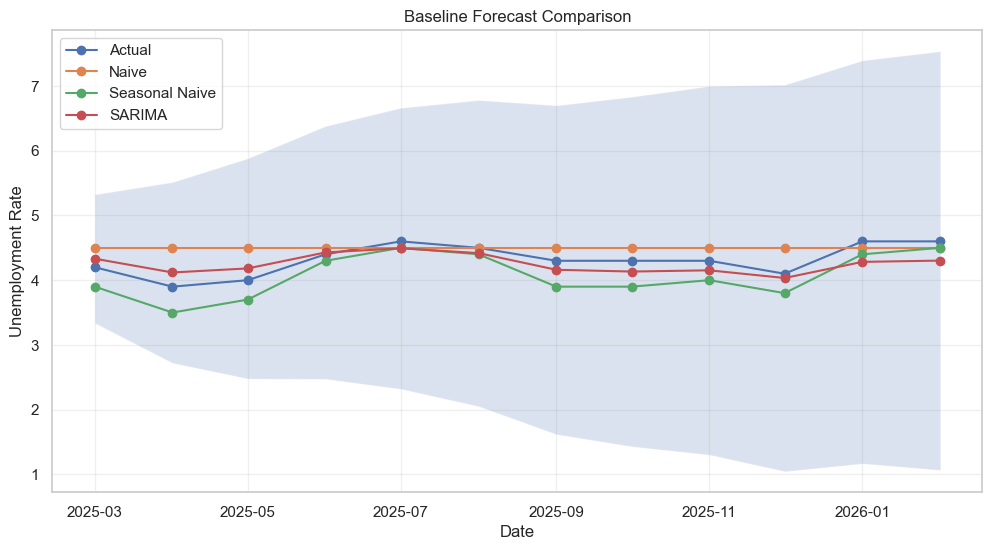

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Actual
plt.plot(test.index, test, label="Actual", marker="o")

# Naive
plt.plot(test.index, naive_forecast, label="Naive", marker="o")

# Seasonal naive
plt.plot(test.index, seasonal_naive, label="Seasonal Naive", marker="o")

# SARIMA
plt.plot(test.index, pred_sarima, label="SARIMA", marker="o")

# SARIMA confidence interval
ci = forecast.conf_int()

plt.fill_between(
    test.index,
    ci.iloc[:, 0],
    ci.iloc[:, 1],
    alpha=0.2
)

plt.title("Baseline Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


#### Baseline SARIMAX

We extend the univariate SARIMA model by including macroeconomic predictors using a SARIMAX framework. Based on economic intuition and correlation analysis, we include initial jobless claims (ICSA), the federal funds rate (FEDFUNDS), and industrial production (INDPRO) as exogenous variables. These variables are expected to capture labor market conditions, monetary policy effects, and overall economic activity.

In [64]:
## Prepare target and predictors
y_exog = data_exog["UNRATENSA"]

X_exog = data_exog[["ICSA", "FEDFUNDS", "INDPRO"]]

print(y_exog.index.min(), y_exog.index.max())
print(X_exog.shape)


1992-01-01 00:00:00 2026-02-01 00:00:00
(410, 3)


In [65]:
## Split / Train 
train_y_sarimax = y_exog.iloc[:-12]
test_y_sarimax = y_exog.iloc[-12:]

train_X_sarimax = X_exog.iloc[:-12]
test_X_sarimax = X_exog.iloc[-12:]

print(train_y.index[-1])
print(test_y.index[0])


2025-02-01 00:00:00
2025-03-01 00:00:00


In [66]:
## Fit SARIMAX Baseline model
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarimax_model = SARIMAX(
    train_y_sarimax,
    exog=train_X_sarimax,
    order=(1,0,0),
    seasonal_order=(1,0,0,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_result = sarimax_model.fit()

print(sarimax_result.summary())


                                     SARIMAX Results                                      
Dep. Variable:                          UNRATENSA   No. Observations:                  398
Model:             SARIMAX(1, 0, 0)x(1, 0, 0, 12)   Log Likelihood                -358.129
Date:                            Fri, 13 Mar 2026   AIC                            728.258
Time:                                    16:15:29   BIC                            751.978
Sample:                                01-01-1992   HQIC                           737.666
                                     - 02-01-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ICSA        2.175e-07   3.77e-08      5.763      0.000    1.44e-07    2.91e-07
FEDFUNDS      -0.1460      0.002   

In [67]:
## Forecast
forecast_sarimax = sarimax_result.get_forecast(
    steps=12,
    exog=test_X_sarimax
)
pred_sarimax = forecast_sarimax.predicted_mean


In [68]:
## Evaluate
mae_sarimax = mean_absolute_error(test_y_sarimax, pred_sarimax)
rmse_sarimax = np.sqrt(mean_squared_error(test_y_sarimax, pred_sarimax))
mape_sarimax = np.mean(np.abs((test_y_sarimax - pred_sarimax) / test_y_sarimax)) * 100

print("SARIMAX")
print(mae_sarimax, rmse_sarimax, mape_sarimax)

SARIMAX
0.07718248647590616 0.0855612033765351 1.7909299713246303


In [69]:
### Compareing models
results_df.loc[len(results_df)] = [
    "SARIMAX",
    mae_sarimax,
    rmse_sarimax,
    mape_sarimax
]

results_df


,Model,MAE,RMSE,MAPE
0,Naive,0.233333,0.291548,5.627627
1,Seasonal Naive,0.250000,0.276887,5.915695
2,SARIMA,0.157080,0.177891,3.635925
3,SARIMAX,0.077182,0.085561,1.790930


The SARIMAX model substantially improves forecast accuracy compared to the univariate SARIMA model. 
Including macroeconomic predictors reduces RMSE from approximately 0.18 to 0.09, indicating that 
labor market conditions are strongly influenced by broader economic variables.

Among the predictors, initial jobless claims and the federal funds rate are statistically significant, 
while industrial production is not significant in the contemporaneous specification. This suggests that 
the effect of economic activity on unemployment may occur with a delay, motivating the use of lagged 
predictors in the next section.


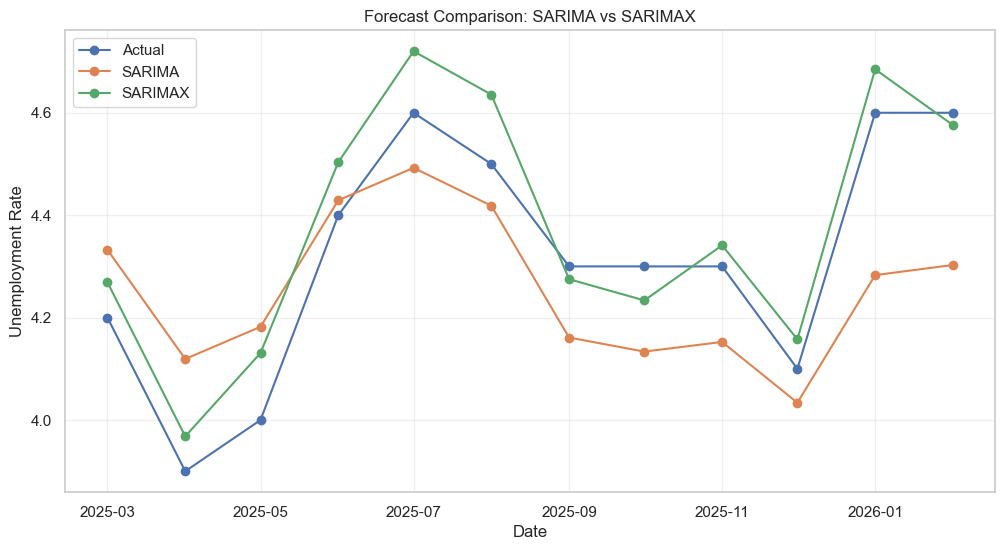

In [70]:
### Forecast Comparision 
plt.figure(figsize=(12,6))

# Actual
plt.plot(test.index, test, label="Actual", marker="o")

# SARIMA
plt.plot(test.index, pred_sarima, label="SARIMA", marker="o")

# SARIMAX
plt.plot(test_y.index, pred_sarimax, label="SARIMAX", marker="o")

plt.title("Forecast Comparison: SARIMA vs SARIMAX")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


### Lagged SARIMAX

The baseline SARIMAX model assumes that macroeconomic variables affect unemployment contemporaneously. 
However, economic effects often occur with delays. For example, changes in interest rates may affect 
employment with a lag, and jobless claims may predict future unemployment.

To capture these delayed effects, we extend the SARIMAX model by including lagged values of the 
exogenous variables. We begin with economically motivated lags, and then test several lag combinations 
to identify the specification that produces the best out-of-sample forecasts.


#### Data prep.

In [71]:
df_lag = data_exog.copy()

df_lag["ICSA_L1"] = df_lag["ICSA"].shift(1)
df_lag["FED_L12"] = df_lag["FEDFUNDS"].shift(12)
df_lag["IND_L6"] = df_lag["INDPRO"].shift(6)

df_lag = df_lag.dropna()

print(df_lag.shape)
print(df_lag.index.min(), df_lag.index.max())


(398, 9)
1993-01-01 00:00:00 2026-02-01 00:00:00


In [75]:
### Train / Test
y_lag = df_lag["UNRATENSA"]

X_lag = df_lag[["ICSA_L1", "FED_L12", "IND_L6"]]

train_y_lag = y_lag.iloc[:-12]
test_y_lag = y_lag.iloc[-12:]

train_X_lag = X_lag.iloc[:-12]
test_X_lag = X_lag.iloc[-12:]

print(train_y_lag.index[-1])
print(test_y_lag.index[0])


2025-02-01 00:00:00
2025-03-01 00:00:00


In [73]:
## Fit Lagged SARIMAX
model_lag = SARIMAX(
    train_y_lag,
    exog=train_X_lag,
    order=(1,0,0),
    seasonal_order=(1,0,0,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

result_lag = model_lag.fit()

print(result_lag.summary())


                                     SARIMAX Results                                      
Dep. Variable:                          UNRATENSA   No. Observations:                  386
Model:             SARIMAX(1, 0, 0)x(1, 0, 0, 12)   Log Likelihood                -433.691
Date:                            Fri, 13 Mar 2026   AIC                            879.383
Time:                                    16:17:31   BIC                            902.912
Sample:                                01-01-1993   HQIC                           888.726
                                     - 02-01-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ICSA_L1    -8.793e-08   3.95e-08     -2.226      0.026   -1.65e-07   -1.05e-08
FED_L12       -0.0907      0.001   

In [74]:
## Forecast
forecast = result_lag.get_forecast(
    steps=12,
    exog=test_X_lag
)

pred_lag = forecast.predicted_mean


In [76]:
## Evalute
mae_lag = mean_absolute_error(test_y_lag, pred_lag)
rmse_lag = np.sqrt(mean_squared_error(test_y_lag, pred_lag))
mape_lag = np.mean(np.abs((test_y_lag - pred_lag) / test_y_lag)) * 100

print(mae_lag, rmse_lag, mape_lag)


0.04712807993408156 0.06771894824242582 1.0990845176295756


In [77]:
## Compare
results_df.loc[len(results_df)] = [
    "SARIMAX_lag",
    mae_lag,
    rmse_lag,
    mape_lag
]

results_df


,Model,MAE,RMSE,MAPE
0,Naive,0.233333,0.291548,5.627627
1,Seasonal Naive,0.250000,0.276887,5.915695
2,SARIMA,0.157080,0.177891,3.635925
3,SARIMAX,0.077182,0.085561,1.790930
4,SARIMAX_lag,0.047128,0.067719,1.099085


Including lagged values of the exogenous variables further improves forecast accuracy. 
The lagged SARIMAX model reduces RMSE from approximately 0.086 in the baseline SARIMAX 
to about 0.068, indicating that delayed effects of macroeconomic variables play an 
important role in predicting unemployment.

In particular, the use of lagged jobless claims, lagged interest rates, and lagged 
industrial production captures the gradual adjustment of the labor market to changes 
in economic conditions. This result is consistent with economic theory, where policy 
changes and business cycle effects often influence unemployment with a delay.

Given this improvement, the next step is to explore several alternative lag combinations 
to verify whether this specification is optimal.


#### EXplore Different Lags

In [79]:
lag_tests = [
    (1,3,6),
    (1,6,3),
    (1,12,6),
    (3,6,6)
]

results_lag_test = []

for l1, l2, l3 in lag_tests:

    df_tmp = data_exog.copy()

    df_tmp["ICSA_L"] = df_tmp["ICSA"].shift(l1)
    df_tmp["FED_L"] = df_tmp["FEDFUNDS"].shift(l2)
    df_tmp["IND_L"] = df_tmp["INDPRO"].shift(l3)

    df_tmp = df_tmp.dropna()

    y_tmp = df_tmp["UNRATENSA"]
    X_tmp = df_tmp[["ICSA_L", "FED_L", "IND_L"]]

    train_y = y_tmp.iloc[:-12]
    test_y = y_tmp.iloc[-12:]

    train_X = X_tmp.iloc[:-12]
    test_X = X_tmp.iloc[-12:]

    model = SARIMAX(
        train_y,
        exog=train_X,
        order=(1,0,0),
        seasonal_order=(1,0,0,12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    res = model.fit(disp=False)

    pred = res.get_forecast(
        steps=12,
        exog=test_X
    ).predicted_mean

    mae = mean_absolute_error(test_y, pred)
    rmse = np.sqrt(mean_squared_error(test_y, pred))
    mape = np.mean(np.abs((test_y - pred) / test_y)) * 100

    results_lag_test.append([l1, l2, l3, mae, rmse, mape])

lag_df = pd.DataFrame(
    results_lag_test,
    columns=["ICSA_lag", "FED_lag", "IND_lag", "MAE", "RMSE", "MAPE"]
)

lag_df


,ICSA_lag,FED_lag,IND_lag,MAE,RMSE,MAPE
0,1,3,6,0.055841,0.069032,1.277330
1,1,6,3,0.092947,0.112994,2.176383
2,1,12,6,0.047128,0.067719,1.099085
3,3,6,6,0.074143,0.094228,1.764348


Among the tested lag combinations, the specification using a 1-month lag for jobless claims,
a 12-month lag for the federal funds rate, and a 6-month lag for industrial production 
produces the lowest forecast error. This model achieves the smallest RMSE among all 
tested specifications and therefore is selected as the final SARIMAX model.

The result suggests that unemployment reacts quickly to changes in jobless claims,
while the effect of monetary policy appears with a longer delay, and industrial production
affects labor market conditions with a medium-term lag. These findings are consistent
with economic intuition and the gradual adjustment of employment to changes in economic activity.


### Covid Dummy Variable Model 

In [80]:
df_covid = data_exog.copy()

df_covid["ICSA_L1"] = df_covid["ICSA"].shift(1)
df_covid["FED_L12"] = df_covid["FEDFUNDS"].shift(12)
df_covid["IND_L6"] = df_covid["INDPRO"].shift(6)

df_covid["COVID"] = 0

df_covid.loc[
    (df_covid.index >= "2020-03-01") &
    (df_covid.index <= "2021-12-01"),
    "COVID"
] = 1

df_covid = df_covid.dropna()


In [81]:
### Fit SARIMAX + dummy
y_covid = df_covid["UNRATENSA"]

X_covid = df_covid[
    ["ICSA_L1", "FED_L12", "IND_L6", "COVID"]
]

train_y_dummy = y_covid.iloc[:-12]
test_y_dummy = y_covid.iloc[-12:]

train_X_dummy = X_covid.iloc[:-12]
test_X_dummy = X_covid.iloc[-12:]

model = SARIMAX(
    train_y_dummy,
    exog=train_X_dummy,
    order=(1,0,0),
    seasonal_order=(1,0,0,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

res = model.fit()

pred = res.get_forecast(
    steps=12,
    exog=test_X_dummy
).predicted_mean

mae_covid = mean_absolute_error(test_y_dummy, pred)
rmse_covid = np.sqrt(mean_squared_error(test_y_dummy, pred))
mape_covid = np.mean(np.abs((test_y_dummy - pred)/test_y_dummy))*100

print(mae_covid, rmse_covid, mape_covid)


0.10040540569997296 0.1228202533930905 2.2907327809429887


In [82]:
results_df.loc[len(results_df)] = [
    "SARIMAX_dummy",
    mae_covid,
    rmse_covid,
    mape_covid
]

results_df


,Model,MAE,RMSE,MAPE
0,Naive,0.233333,0.291548,5.627627
1,Seasonal Naive,0.250000,0.276887,5.915695
2,SARIMA,0.157080,0.177891,3.635925
3,SARIMAX,0.077182,0.085561,1.790930
4,SARIMAX_lag,0.047128,0.067719,1.099085
5,SARIMAX_dummy,0.100405,0.122820,2.290733


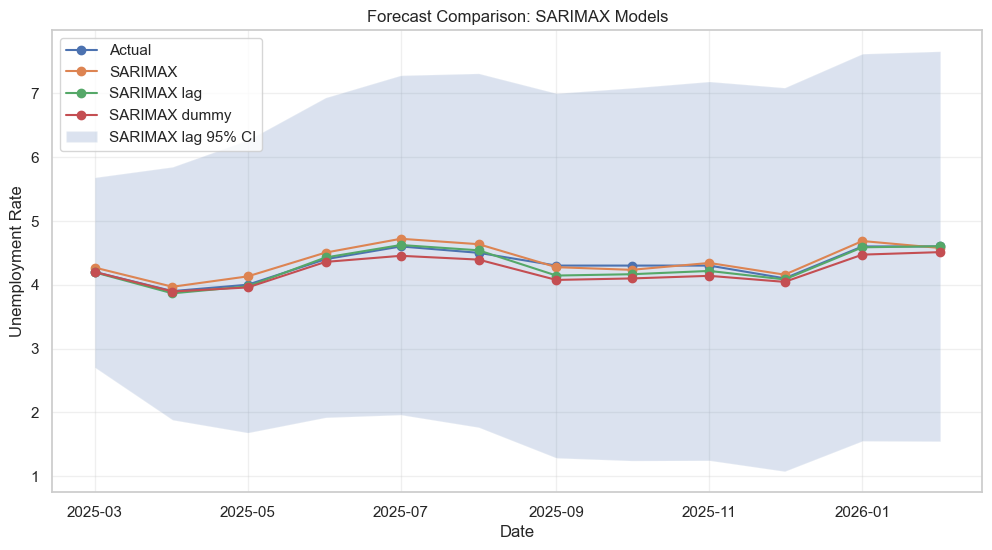

In [84]:
### Forecasting
# Recreate forecasts using the renamed test sets
forecast_sarimax = sarimax_result.get_forecast(
    steps=12,
    exog=test_X_sarimax
)
pred_sarimax = forecast_sarimax.predicted_mean

forecast_lag = result_lag.get_forecast(
    steps=12,
    exog=test_X_lag
)
pred_lag = forecast_lag.predicted_mean

forecast_dummy = res.get_forecast(
    steps=12,
    exog=test_X_dummy
)
pred_dummy = forecast_dummy.predicted_mean

# Use one common actual series
actual = test_y_lag

# Confidence interval from best model
ci_lag = forecast_lag.conf_int()

plt.figure(figsize=(12, 6))

plt.plot(actual.index, actual, label="Actual", marker="o")
plt.plot(actual.index, pred_sarimax, label="SARIMAX", marker="o")
plt.plot(actual.index, pred_lag, label="SARIMAX lag", marker="o")
plt.plot(actual.index, pred_dummy, label="SARIMAX dummy", marker="o")

plt.fill_between(
    actual.index,
    ci_lag.iloc[:, 0],
    ci_lag.iloc[:, 1],
    alpha=0.2,
    label="SARIMAX lag 95% CI"
)

plt.title("Forecast Comparison: SARIMAX Models")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Other plotting

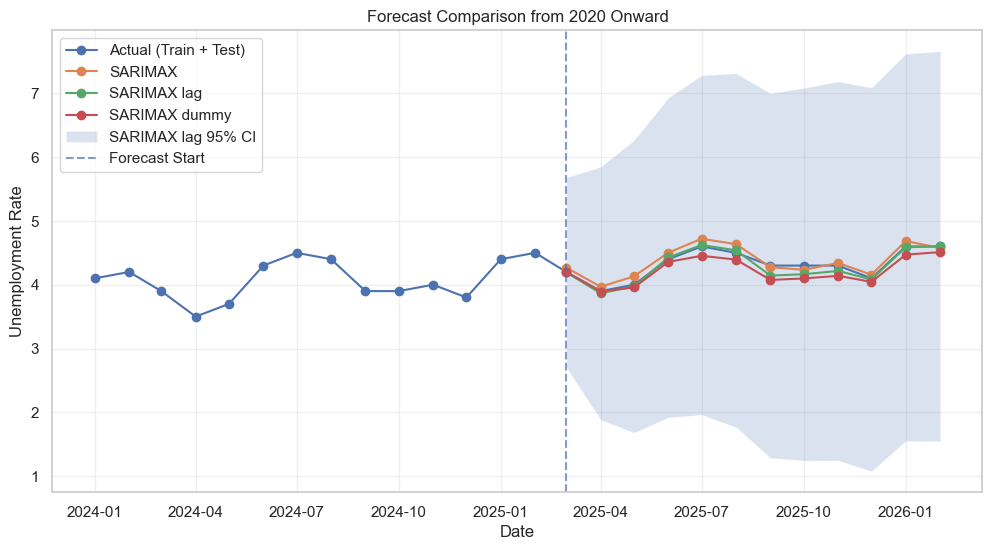

In [88]:
import matplotlib.pyplot as plt

# Recreate forecasts if needed
forecast_sarimax = sarimax_result.get_forecast(
    steps=12,
    exog=test_X_sarimax
)
pred_sarimax = forecast_sarimax.predicted_mean

forecast_lag = result_lag.get_forecast(
    steps=12,
    exog=test_X_lag
)
pred_lag = forecast_lag.predicted_mean

forecast_dummy = res.get_forecast(
    steps=12,
    exog=test_X_dummy
)
pred_dummy = forecast_dummy.predicted_mean

# Confidence interval for best model
ci_lag = forecast_lag.conf_int()

# Use the lagged-model full series so train + test are in one line
full_series = pd.concat([train_y_lag, test_y_lag])

# Keep only 2020 onward
plot_start = "2024-01-01"
full_plot = full_series.loc[plot_start:]
actual_test = test_y_lag.loc[plot_start:]
pred_sarimax_plot = pred_sarimax.loc[plot_start:]
pred_lag_plot = pred_lag.loc[plot_start:]
pred_dummy_plot = pred_dummy.loc[plot_start:]
ci_lag_plot = ci_lag.loc[plot_start:]

plt.figure(figsize=(12, 6))

# Recent training + test actuals
plt.plot(full_plot.index, full_plot, label="Actual (Train + Test)", marker="o")

# Forecasts
plt.plot(pred_sarimax_plot.index, pred_sarimax_plot, label="SARIMAX", marker="o")
plt.plot(pred_lag_plot.index, pred_lag_plot, label="SARIMAX lag", marker="o")
plt.plot(pred_dummy_plot.index, pred_dummy_plot, label="SARIMAX dummy", marker="o")

# Confidence interval for best model
plt.fill_between(
    ci_lag_plot.index,
    ci_lag_plot.iloc[:, 0],
    ci_lag_plot.iloc[:, 1],
    alpha=0.2,
    label="SARIMAX lag 95% CI"
)

# Vertical line where forecast starts
plt.axvline(test_y_lag.index[0], linestyle="--", alpha=0.7, label="Forecast Start")

plt.title("Forecast Comparison from 2020 Onward")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


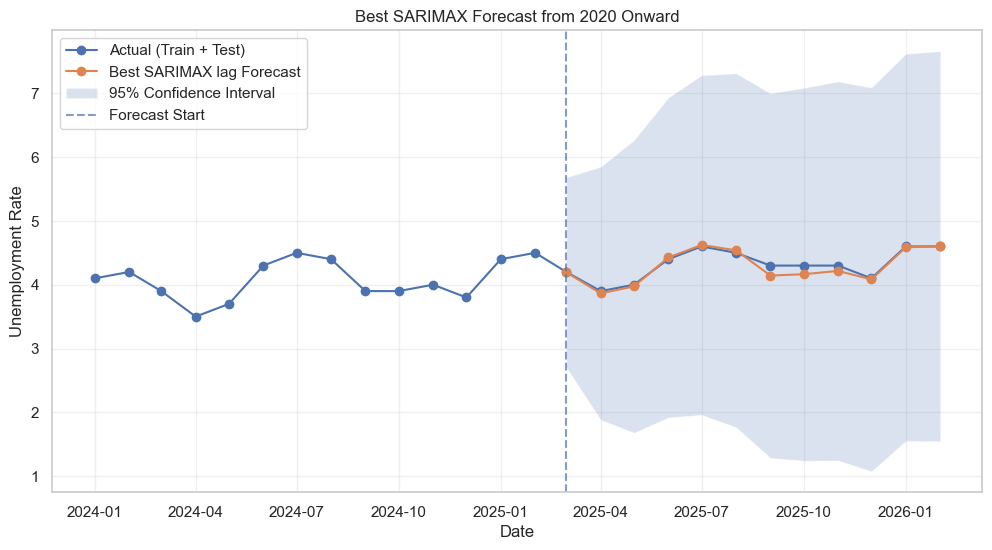

In [87]:
import matplotlib.pyplot as plt

# Forecast from best model
forecast_lag = result_lag.get_forecast(
    steps=12,
    exog=test_X_lag
)
pred_lag = forecast_lag.predicted_mean
ci_lag = forecast_lag.conf_int()

# Actual full series for recent context
full_series = pd.concat([train_y_lag, test_y_lag])

# Keep only 2020 onward
plot_start = "2024-01-01"
full_plot = full_series.loc[plot_start:]
pred_lag_plot = pred_lag.loc[plot_start:]
ci_lag_plot = ci_lag.loc[plot_start:]

plt.figure(figsize=(12, 6))

plt.plot(full_plot.index, full_plot, label="Actual (Train + Test)", marker="o")
plt.plot(pred_lag_plot.index, pred_lag_plot, label="Best SARIMAX lag Forecast", marker="o")

plt.fill_between(
    ci_lag_plot.index,
    ci_lag_plot.iloc[:, 0],
    ci_lag_plot.iloc[:, 1],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.axvline(test_y_lag.index[0], linestyle="--", alpha=0.7, label="Forecast Start")

plt.title("Best SARIMAX Forecast from 2020 Onward")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Final Results and Discussion

This study evaluated several time series models to forecast the monthly unemployment rate using both univariate and multivariate approaches. The analysis began with simple benchmark models and gradually introduced additional structure based on economic intuition and empirical diagnostics.

The naive and seasonal naive models provided a useful baseline for comparison but produced relatively large forecast errors. The univariate SARIMA model improved forecast accuracy by capturing the strong persistence and seasonal structure observed in the unemployment series. This confirmed that the unemployment rate follows a highly autocorrelated process with annual seasonality.

Next, the model was extended to a SARIMAX framework by incorporating macroeconomic predictors, including initial jobless claims, the federal funds rate, and industrial production. Adding these variables substantially improved forecast performance, indicating that labor market conditions are strongly influenced by broader economic activity.

To account for delayed economic effects, lagged versions of the predictors were introduced. Testing several lag combinations showed that the best performance was achieved using a one-month lag for jobless claims, a twelve-month lag for the federal funds rate, and a six-month lag for industrial production. This specification produced the lowest forecast error among all tested models. The result suggests that unemployment reacts quickly to changes in jobless claims, while monetary policy and production affect the labor market with longer delays. These findings are consistent with economic theory, where employment adjusts gradually to changes in economic conditions.

A robustness check was conducted by including a dummy variable for the COVID-19 pandemic period. The model with the dummy variable produced worse out-of-sample forecasts than the lagged SARIMAX model. This indicates that the macroeconomic predictors already capture most of the pandemic-related dynamics, and explicitly modeling the shock does not improve forecasting accuracy.

Overall, the lagged SARIMAX model provided the best balance between statistical fit, forecasting performance, and economic interpretability. The results highlight the importance of including both seasonal dynamics and lagged macroeconomic variables when forecasting unemployment at the monthly frequency.
